In [3]:
import tensorflow as tf
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop
from keras import backend as KerasTensor

In [4]:
#load data
import numpy as np
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Reshape input data to include the channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype(np.float32) / 255
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype(np.float32) / 255

#convert labels to one hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
def build_model (optimizer):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPool2D((2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model
    

In [ ]:
optimizers = ['adadelta', 'SGD', 'Adam', 'Rmsprop', 'Adagrad']
history_disc = {}
for opt in optimizers:
    print("Running optimization algorithms:{}".format(opt))
    model = build_model(opt)
    history_disc[opt] = model.fit(x_train, y_train,
                                batch_size=64,
                                epochs=10,
                                verbose=1,
                                validation_data=(x_test, y_test)
                                )
    optimizers = ['adadelta', 'SGD', 'Adam', 'Rmsprop', 'Adagrad']
    history_disc = {}
    for opt in optimizers:
        print(f"Running optimization algorithm: {opt}")
        history_disc[opt] = build_model(opt).fit(
            x_train, y_train,
            batch_size=64,
            epochs=10,
            verbose=1,
            validation_data=(x_test, y_test)
        )

Running optimization algorithms:adadelta


/workspaces/AI-and-NN/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.1677 - loss: 2.2742 - val_accuracy: 0.3769 - val_loss: 2.2203
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.2822 - loss: 2.2007 - val_accuracy: 0.5327 - val_loss: 2.1365
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.3835 - loss: 2.1200 - val_accuracy: 0.6292 - val_loss: 2.0409
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.4568 - loss: 2.0289 - val_accuracy: 0.6854 - val_loss: 1.9323
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.5124 - loss: 1.9265 - val_accuracy: 0.7214 - val_loss: 1.8135
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.5515 - loss: 1.8191 - val_accuracy: 0.7438 - val_loss: 1.6906
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.5868 - loss: 1.7062 - val_accuracy: 0.7635 - val_loss: 1.5664
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.6104 - loss: 1.5979 - 

KeyError: 'SGD'

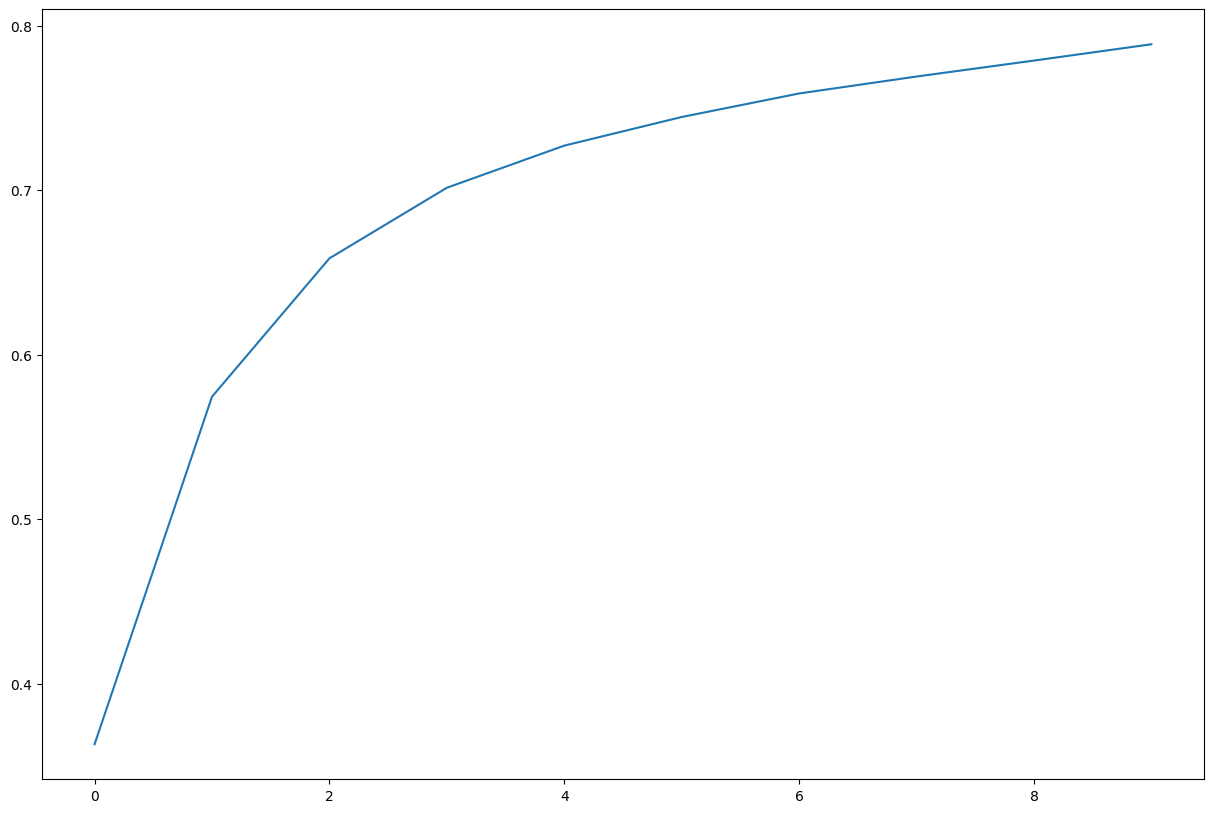

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(15, 10))
for opt in optimizers:
    if opt in history_disc:
        plt.plot(history_disc[opt].history['val_accuracy'], label=opt)

plt.xlabel('Epoch') 
plt.title('Validation Accuracy for Different Optimizers')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()
